A model of the form:

$$
\frac{dy}{de} = f(y, de)
$$

where:

* $y$ includes **stress** and **internal state variables** (e.g., plastic strain, damage, etc.),
* $e$ is the **strain**,
* $de$ is the **strain increment**,
* and $f$ is modeled by a **Gaussian Process (GP)**.

The goal is to **accurately learn cyclic deformation behavior** with **minimal data**. This is a data-efficient learning problem in a dynamical setting. Here’s a strategy tailored to our setup:

---

## ✅ Key Ideas for Training with Minimal Data

### 1. **Formulate as a Recursive Integration Problem**

Since you're modeling $\frac{dy}{de} = f(y, de)$, you'll integrate the GP to simulate forward in strain space:

```python
y_{k+1} = y_k + f(y_k, de_k) * de_k
```

Use this to **rollout** trajectories from your GP model. Accuracy of long rollouts is a key training criterion.

---

### 2. **Design Cyclic Training Trajectories Carefully**

Use a **minimum set of representative cyclic strain paths** and prioritize:

* **Primitive cycles** (each strain component separately),
* **Mixed cycles** (proportional and non-proportional loading),
* **Low and high amplitude**, and **asymmetric paths**.

Train on these minimal cycles but validate on diverse unseen paths.

---

### 3. **Use Active Learning / Bayesian Experimental Design**

Train your GP model with an **active learning loop**:

* Start with a few base strain paths.
* Use uncertainty in the GP (e.g., variance of $f$) to identify where predictions are uncertain.
* Add trajectories (or increments) that reduce this uncertainty.

This way, the model focuses data collection where it’s least confident — often at yield points, reversals, ratcheting transitions, etc.

---

### 4. **Augment Input Space with Phase Info**

To handle cyclic behavior well, include **history-aware features**:

* Add variables like **number of reversals**, **cumulative strain**, or **damage indicators** to the input of $f$.
* Use **internal state variables** that evolve cyclically (e.g., back stress, kinematic hardening).

This lets the GP distinguish loading/unloading, and remember the material's state.

---

### 5. **GP Model Selection and Regularization**

Use a GP kernel that handles interactions in $(y, de)$:

* Use **ARD kernels** (Automatic Relevance Determination) to learn input importance.
* Combine **RBF kernel for smoothness** + **periodic kernel** to model cyclic structure.
* Try **multi-output GPs** (e.g., DeepGP or LMC kernels) to handle stress and internal variables jointly.

---

### 6. **Physics-Informed GP (Optional)**

If prior knowledge is available, embed physical constraints:

* Monotonicity or symmetry in stress-strain curves,
* Known flow rules or evolution laws (e.g., linear elasticity at small strains).

This can reduce the learning burden and improve extrapolation.

---

## 🔁 Suggested Workflow

1. **Define 10–15 representative strain paths**.
2. **Simulate or obtain true data** for these (e.g., via FEM, experiments).
3. **Train GP model** using $(y_k, de_k) \mapsto dy_k$ pairs.
4. **Rollout** the model forward in strain for new paths.
5. **Measure error**, and use **active learning** to request new data where GP is uncertain.
6. Repeat until generalization error is acceptable.

---

Would you like an example notebook that simulates this GP training on synthetic cyclic data, or outlines the active learning loop?


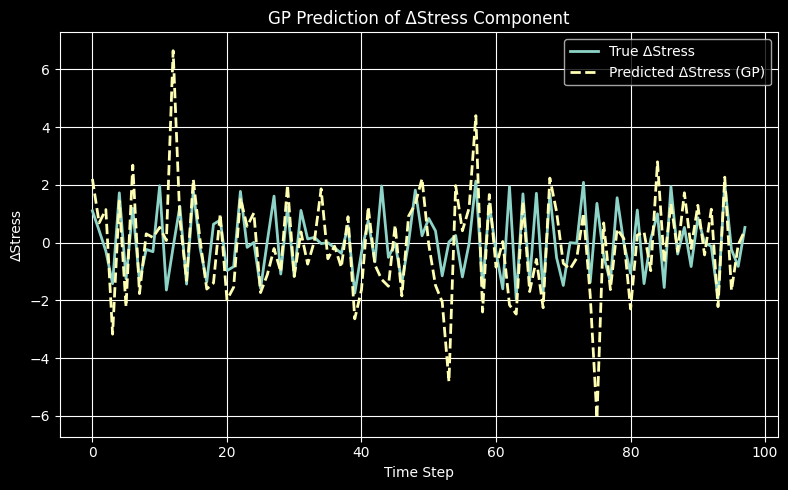

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------------- GP Components ---------------- #

def rbf_kernel(x1, x2, lengthscale=1.0, variance=1.0):
    sqdist = jnp.sum((x1 - x2) ** 2)
    return variance * jnp.exp(-0.5 * sqdist / lengthscale ** 2)

def compute_kernel_matrix(X1, X2, lengthscale=1.0, variance=1.0, noise=1e-6):
    def kernel_fn(x1, x2):
        return rbf_kernel(x1, x2, lengthscale, variance)
    K = jax.vmap(lambda x1: jax.vmap(lambda x2: kernel_fn(x1, x2))(X2))(X1)
    if X1.shape[0] == X2.shape[0]:
        K += noise * jnp.eye(X1.shape[0])
    return K

def gp_train_and_predict(X_train, y_train, X_test, lengthscale=1.0, variance=1.0, noise=1e-6):
    K = compute_kernel_matrix(X_train, X_train, lengthscale, variance, noise)
    K_s = compute_kernel_matrix(X_test, X_train, lengthscale, variance)
    K_ss = compute_kernel_matrix(X_test, X_test, lengthscale, variance)
    K_inv = jnp.linalg.inv(K + noise * jnp.eye(K.shape[0]))
    mu = K_s @ K_inv @ y_train
    cov = K_ss - K_s @ K_inv @ K_s.T
    return mu, cov

# ---------------- Data Generator ---------------- #

def generate_synthetic_data(N_traj=10, N_pts=50, D=2, key=jax.random.PRNGKey(0)):
    strain_data = jax.random.uniform(key, (N_traj, N_pts, D), minval=-1.0, maxval=1.0)
    stress_data = jnp.sin(strain_data * jnp.pi) + 0.1 * jax.random.normal(key, (N_traj, N_pts, D))
    return strain_data, stress_data

def build_gp_training_data(strain_trajs, stress_trajs):
    N_traj, N_pts, D = strain_trajs.shape
    X_list, y_list = [], []
    for traj in range(N_traj):
        strain, stress = strain_trajs[traj], stress_trajs[traj]
        de = strain[1:] - strain[:-1]
        dy = stress[1:] - stress[:-1]
        y_prev = stress[:-1]
        X = jnp.concatenate([y_prev, de], axis=1)
        X_list.append(X)
        y_list.append(dy)
    return jnp.concatenate(X_list), jnp.concatenate(y_list)

# ---------------- Run & Visualize ---------------- #

# Generate synthetic cyclic-ish data
key = jax.random.PRNGKey(42)
strain, stress = generate_synthetic_data(N_traj=10, N_pts=50, D=2, key=key)

# Split into train/test
strain_train, stress_train = strain[:8], stress[:8]
strain_test, stress_test = strain[8:], stress[8:]

X_train, y_train = build_gp_training_data(strain_train, stress_train)
X_test, y_true = build_gp_training_data(strain_test, stress_test)

# Standardize input for better GP results
scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Train & predict
mu, cov = gp_train_and_predict(X_train_scaled, y_train, X_test_scaled)

# ---------------- Plotting ---------------- #

# Pick one component (e.g., stress component 0) to plot
fig, ax = plt.subplots(figsize=(8, 5))
idx_plot = 0
ax.plot(y_true[:, idx_plot], label="True ΔStress", linewidth=2)
ax.plot(mu[:, idx_plot], '--', label="Predicted ΔStress (GP)", linewidth=2)
ax.set_title("GP Prediction of ΔStress Component")
ax.set_xlabel("Time Step")
ax.set_ylabel("ΔStress")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
